In [2]:
#!pip install gpflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 382.0/382.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 40.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26

In [1]:
import os
import time
import numpy as np
import pandas as pd
from scipy.stats import binom
import tensorflow as tf
import gpflow

gpflow.config.set_default_float(np.float64)

In [5]:
def true_binomial_pmf(grid_p, n_binom=10):
    P = np.zeros((len(grid_p), n_binom + 1))
    for i, p in enumerate(grid_p):
        P[i, :] = binom.pmf(np.arange(n_binom + 1), n=n_binom, p=p)
    return P

def integrated_distances(P_est, P_true, eps=1e-12):
    P_est = np.clip(P_est, eps, 1.0)
    P_est = P_est / P_est.sum(axis=1, keepdims=True)

    P_true = np.clip(P_true, eps, 1.0)
    P_true = P_true / P_true.sum(axis=1, keepdims=True)

    CDF_est = np.cumsum(P_est, axis=1)
    CDF_true = np.cumsum(P_true, axis=1)

    W1_grid = np.sum(np.abs(CDF_est - CDF_true), axis=1)

    KL_EstTrue_grid = np.sum(
        P_est * np.log(P_est / P_true),
        axis=1
    )

    KL_TrueEst_grid = np.sum(
        P_true * np.log(P_true / P_est),
        axis=1
    )

    TV_grid = np.sum(
        np.abs(P_est - P_true),
        axis=1
    )

    H_grid = np.sqrt(
        0.5 * np.sum(
            (np.sqrt(P_true) - np.sqrt(P_est)) ** 2,
            axis=1
        )
    )

    return {
        "W1": np.mean(W1_grid),
        "KL_EstTrue": np.mean(KL_EstTrue_grid),
        "KL_TrueEst": np.mean(KL_TrueEst_grid),
        "TV": np.mean(TV_grid),
        "H": np.mean(H_grid),
        "grid": {
            "W1": W1_grid,
            "KL_EstTrue": KL_EstTrue_grid,
            "KL_TrueEst": KL_TrueEst_grid,
            "TV": TV_grid,
            "H": H_grid,
            }
    }

def fit_multiclass_gp_nKnown(df_train, K=11, lengthscale=0.25, variance=1.0, n_inducing=31, maxiter=10000):
    X = df_train[["p"]].to_numpy(dtype=np.float64)
    Y = df_train[["output"]].to_numpy(dtype=np.int64)

    # inducing points on [0,1]
    Z = np.linspace(0.0, 1.0, n_inducing).reshape(-1, 1)


    kernel = gpflow.kernels.SquaredExponential(
        variance=variance,
        lengthscales=lengthscale
    )

    # sum kernel: Matern52 + White
    kernel = gpflow.kernels.Matern52(variance=variance, lengthscales=lengthscale) + gpflow.kernels.White(variance=variance*0.01)

    likelihood = gpflow.likelihoods.MultiClass(num_classes=K)  # Multiclass likelihood

    # SVGP
    model = gpflow.models.SVGP(
        kernel=kernel,
        likelihood=likelihood,
        inducing_variable=Z,
        num_latent_gps=K,
        whiten=True,
        q_diag=True,
    )

    gpflow.set_trainable(model.inducing_variable.Z, False)

    data = (X, Y)

    opt = gpflow.optimizers.Scipy()
    opt.minimize(
        model.training_loss_closure(data),
        model.trainable_variables,
        options={"maxiter": maxiter}
    )

    return model

def predict_class_prob(model, p_grid):
    Xnew = np.asarray(p_grid, dtype=np.float64).reshape(-1, 1)

    # GPflow returns predictive class probabilities for MultiClass likelihood
    mean, var = model.predict_y(Xnew)

    P = mean.numpy()

    # defensive normalization
    P = np.clip(P, 1e-12, 1.0)
    P = P / P.sum(axis=1, keepdims=True)

    return P

def predict_class_prob_mc(
    model,
    p_grid,
    n_samples=100,
    eps=1e-12
):
    """
    Monte Carlo predictive class probabilities.
    """

    Xnew = np.asarray(p_grid).reshape(-1, 1)

    F_samples = model.predict_f_samples(
        Xnew,
        num_samples=n_samples
    ).numpy()

    # softmax
    F_samples = F_samples - np.max(
        F_samples,
        axis=-1,
        keepdims=True
    )

    expF = np.exp(F_samples)

    P_samples = expF / np.sum(
        expF,
        axis=-1,
        keepdims=True
    )

    P_samples = np.clip(P_samples, eps, 1.0)

    # posterior mean probabilities
    P_mean = P_samples.mean(axis=0)

    P_mean = P_mean / P_mean.sum(
        axis=-1,
        keepdims=True
    )

    return P_mean, P_samples


In [3]:
# %%
n_binom = 10
K = n_binom + 1
seeds = range(1, 10+1)

n_start = 10
n_end = 38          # same number of sequential iterations as SLGP
batch_size = 5      # same: 5 observations at each selected p

out_dir = "res_synth/case1_seq/GPflow_multiclass"
in_dir = "res_synth/case1_seq/datasets"
os.makedirs(out_dir, exist_ok=True)

grid_p = np.linspace(0.0, 1.00, 101)
classes = np.arange(K)

P_true = true_binomial_pmf(grid_p, n_binom=n_binom)

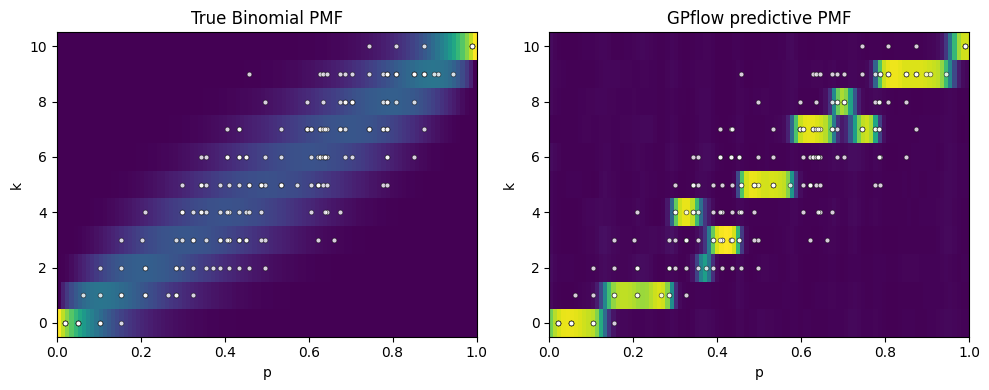

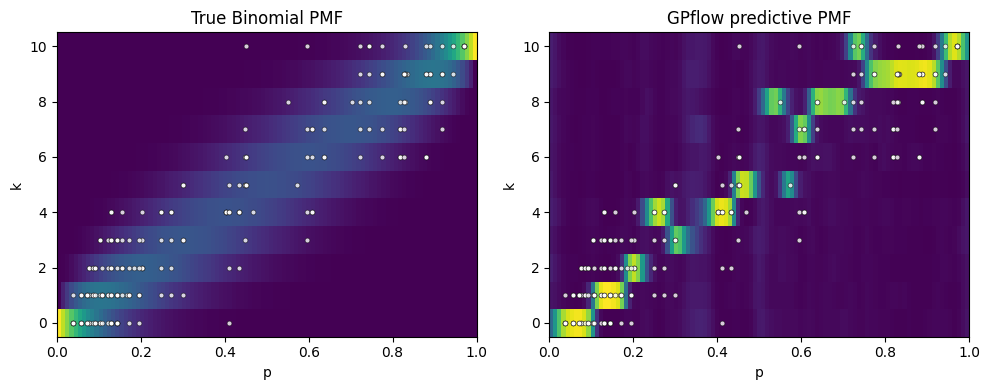

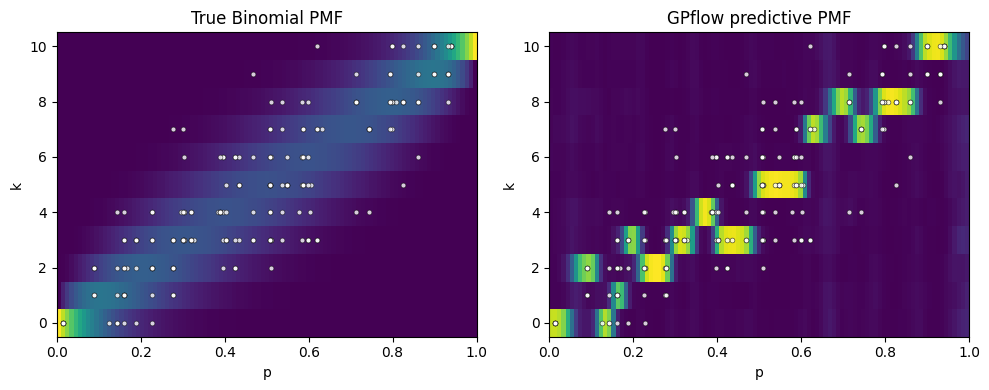

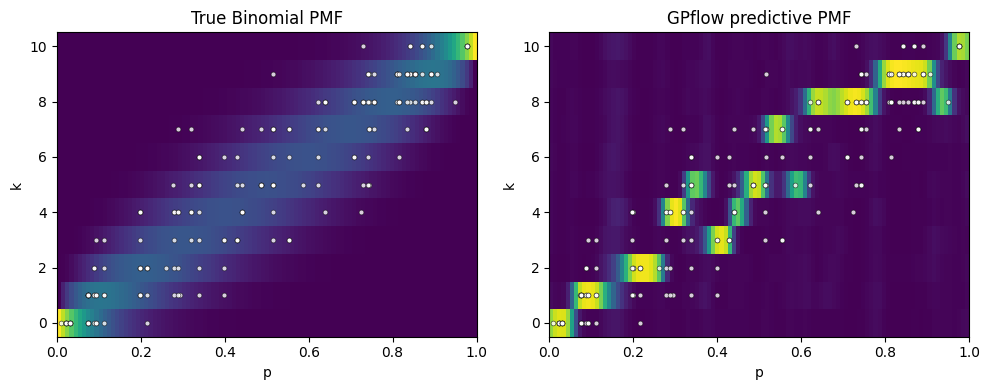

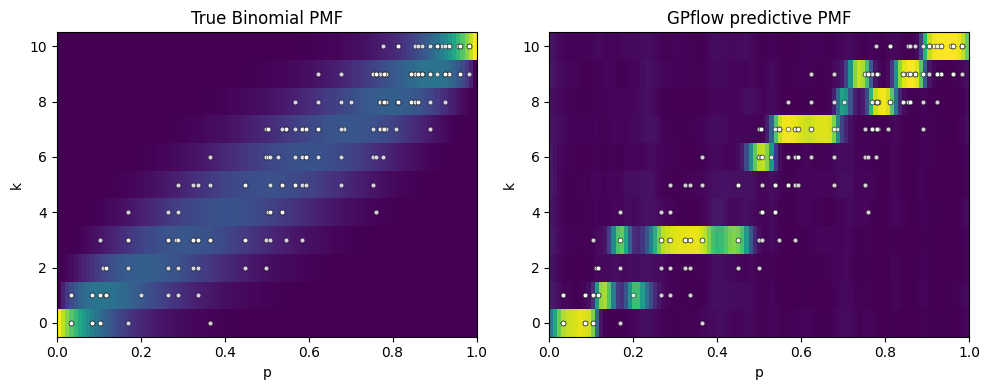

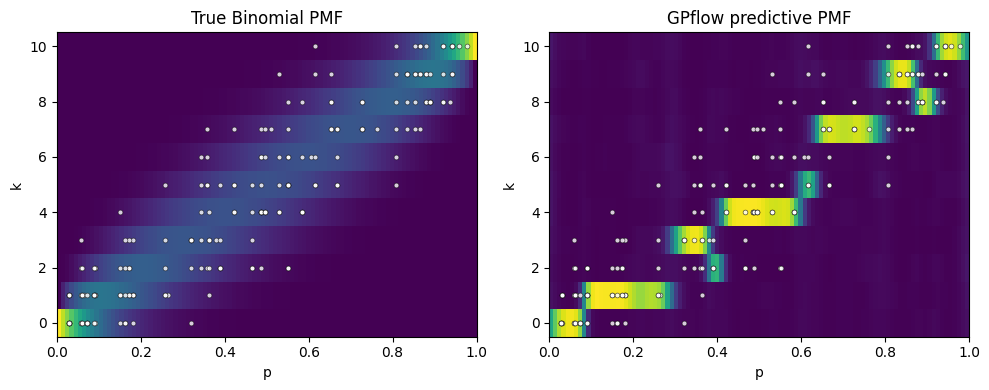

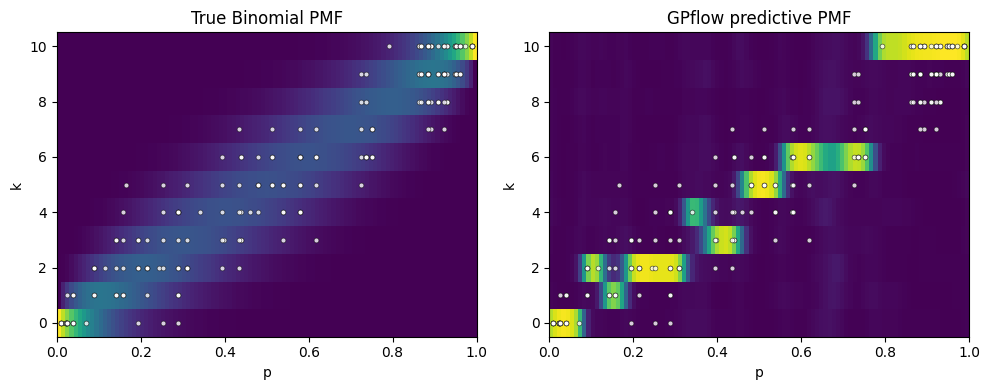

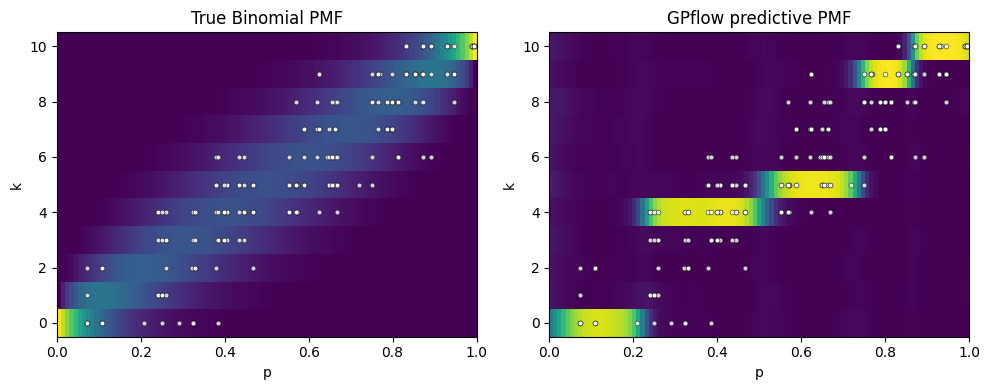

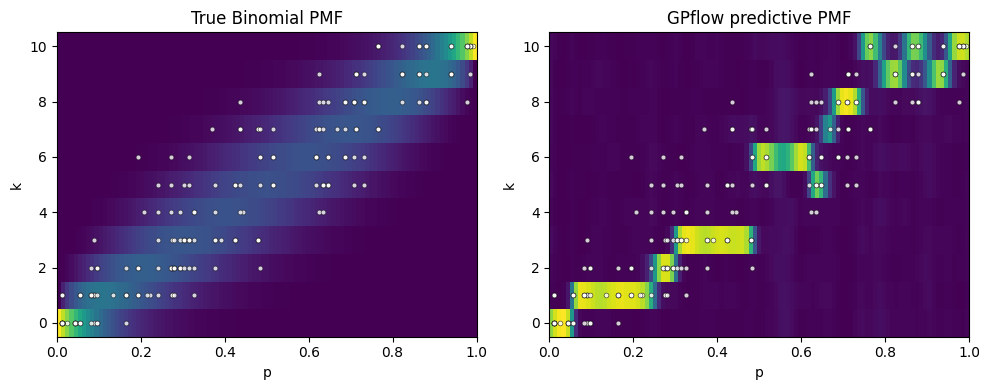

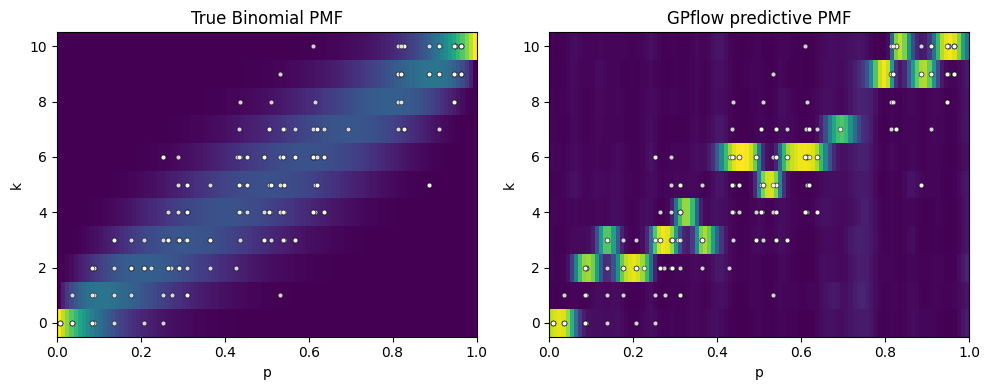

In [6]:
for seed in range(1, 11):
  df_full = pd.read_csv(in_dir+f"/random_seed{seed}.csv")

  step=200
  df_train = df_full.iloc[:step].copy()

  X = df_train[["p"]].to_numpy(dtype=np.float64)
  Y = df_train[["output"]].to_numpy(dtype=np.int64)

  model = fit_multiclass_gp_nKnown(df_train)

  P_gp, _ = predict_class_prob_mc(model=model, p_grid=grid_p)

  import matplotlib.pyplot as plt

  fig, ax = plt.subplots(1, 2, figsize=(10, 4))

  im0 = ax[0].imshow(
      P_true.T,
      aspect="auto",
      origin="lower",
      extent=[grid_p.min(), grid_p.max(), 0-0.5, n_binom+0.5]
  )
  ax[0].set_title("True Binomial PMF")


  im1 = ax[1].imshow(
      P_gp.T,
      aspect="auto",
      origin="lower",
      extent=[grid_p.min(), grid_p.max(), 0-0.5, n_binom+0.5]
  )
  ax[1].set_title("GPflow predictive PMF")

  # observed training data
  for a in ax:
      a.scatter(
          df_train["p"],
          df_train["output"],
          s=12,
          c="white",
          edgecolors="black",
          linewidths=0.4,
          alpha=0.8,
          label="Training data"
      )
      a.set_xlabel("p")
      a.set_ylabel("k")

  plt.tight_layout()

  fig_file = os.path.join(
      out_dir,
      f"pmf_comparison_gpflow_seed{seed}_n{step}.png"
  )

  fig.savefig(
      fig_file,
      dpi=300,
      bbox_inches="tight"
  )

# Sequential design of experiment: n is known
## Random design

In [7]:
for seed in seeds:
    df_full  = pd.read_csv(in_dir+f"/random_seed{seed}.csv")
    for step in [10, 50, 100, 150, 200]:
        df_train = df_full.iloc[:step].copy()

        t0 = time.time()

        model = fit_multiclass_gp_nKnown(
            df_train,
            K=K,
            lengthscale=0.25,
            variance=1.0,
            n_inducing=min(30, len(df_train)),
            maxiter=1000
        )

        fit_time = time.time() - t0

        P_gp = predict_class_prob(model, grid_p)
        dist = integrated_distances(P_gp, P_true)

        # -----------------------------------
        # Save summary
        # -----------------------------------

        summary_step = pd.DataFrame([{
            "seed": seed,
            "step": step,
            "n": len(df_train),
            "method": "GPflow_multiclass_GP",
            "design": "random",
            "W1": dist["W1"],
            "KL_EstTrue": dist["KL_EstTrue"],
            "KL_TrueEst": dist["KL_TrueEst"],
            "fit_time_sec": fit_time
        }])

        summary_file = os.path.join(
            out_dir,
            f"summary_seed{seed}_step{step}_n{len(df_train)}.csv"
        )

        summary_step.to_csv(
            summary_file,
            index=False
        )

        # -----------------------------------
        # Save predictive pmf
        # -----------------------------------

        pred_df = pd.DataFrame(
            P_gp,
            columns=[f"prob_{k}" for k in range(K)]
        )

        pred_df.insert(0, "p", grid_p)

        pred_file = os.path.join(
            out_dir,
            f"pred_seed{seed}_n{len(df_train)}.csv"
        )

        pred_df.to_csv(
            pred_file,
            index=False
        )

        print(
            f"seed={seed} | step={step} | n={len(df_train)} | "
            f"IKL={dist["KL_TrueEst"]:.4f} | fit={fit_time:.2f}s"
        )

seed=1 | step=10 | n=10 | IKL=1.8336 | fit=2.47s
seed=1 | step=50 | n=50 | IKL=1.6065 | fit=2.33s
seed=1 | step=100 | n=100 | IKL=2.1983 | fit=3.52s
seed=1 | step=150 | n=150 | IKL=2.4872 | fit=3.73s
seed=1 | step=200 | n=200 | IKL=2.6282 | fit=6.56s
seed=2 | step=10 | n=10 | IKL=1.7244 | fit=1.89s
seed=2 | step=50 | n=50 | IKL=2.5580 | fit=2.10s
seed=2 | step=100 | n=100 | IKL=1.7074 | fit=4.28s
seed=2 | step=150 | n=150 | IKL=1.7910 | fit=4.14s
seed=2 | step=200 | n=200 | IKL=1.9474 | fit=5.01s
seed=3 | step=10 | n=10 | IKL=1.5034 | fit=2.71s
seed=3 | step=50 | n=50 | IKL=1.4208 | fit=2.43s
seed=3 | step=100 | n=100 | IKL=1.8070 | fit=3.14s
seed=3 | step=150 | n=150 | IKL=2.2901 | fit=3.92s
seed=3 | step=200 | n=200 | IKL=2.3748 | fit=5.22s
seed=4 | step=10 | n=10 | IKL=1.4796 | fit=1.91s
seed=4 | step=50 | n=50 | IKL=1.2681 | fit=2.39s
seed=4 | step=100 | n=100 | IKL=1.8554 | fit=4.94s
seed=4 | step=150 | n=150 | IKL=1.9396 | fit=4.31s
seed=4 | step=200 | n=200 | IKL=2.2667 | fit=4.

In [8]:
import shutil

shutil.make_archive(
    "GPflow_multiclass",
    "zip",
    "./res_synth/case1_seq"
)

'/content/GPflow_multiclass.zip'

In [134]:
#shutil.rmtree("./res_synth/case1_seq/GPflow_multiclass")